In [2]:
import pandas as pd
import zipfile
import io
import sys, os
from pathlib import Path
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm

# 本地数据
一个包含约500只印度股票的1分钟级别OHLCV数据集（2015–2026），主要用于练习高频数据处理和简单策略测试。

In [3]:
zip_path = "/mnt/c/Users/shuol/Desktop/archive.zip"
all_stocks = []

with zipfile.ZipFile(zip_path, 'r') as z:
    csv_files = [f for f in z.namelist() if f.endswith('.csv')][:100]
    
    for file_name in tqdm(csv_files, desc="Loading CSVs"):
        with z.open(file_name) as f:
            df = pd.read_csv(f)
            df.columns = [c.lower() for c in df.columns]
            
            # Downcast numerical columns to save up to 50% memory
            float_cols = df.select_dtypes(include=['float64']).columns
            df[float_cols] = df[float_cols].astype('float32')
            
            int_cols = df.select_dtypes(include=['int64']).columns
            df[int_cols] = df[int_cols].astype('int32')
            
            #Add symbol
            symbol = os.path.basename(file_name).replace('_minute.csv', '').replace('.csv', '')
            df['symbol'] = symbol
            
            all_stocks.append(df)

# 合并成一个大 DataFrame
df_main = pd.concat(all_stocks, axis=0, ignore_index=True)

# Free up memory immediately
del all_stocks 

# Convert symbol to category 
df_main['symbol'] = df_main['symbol'].astype('category')

#Parse dates AFTER concat to avoid doing it 100 separate times
df_main['date'] = pd.to_datetime(df_main['date'])

df_main.set_index(['date', 'symbol'], inplace=True)
df_main.sort_index(inplace=True)

Loading CSVs: 100%|███████████████████████████████████████████████████████████████████| 100/100 [01:45<00:00,  1.05s/it]


In [5]:
df_daily = df_main.groupby('symbol').resample('D', level='date').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'})

df_daily = df_daily.swaplevel().sort_index()
df_daily.dropna(subset=['close'], inplace=True)

In [6]:
df_daily

open         high          low        close  \
date       symbol                                                           
2015-02-02 360ONE        57.799999    58.750000    56.650002    56.849998   
           3MINDIA     6799.000000  6969.950195  6799.000000  6888.049805   
           AARTIIND      72.150002    75.000000    70.099998    74.050003   
           ABB         1000.849976  1011.799988   982.049988   986.750000   
           ABBOTINDIA  4040.000000  4070.000000  3936.699951  4024.000000   
...                            ...          ...          ...          ...   
2026-01-23 CANFINHOME   912.500000   915.000000   900.000000   903.349976   
           CAPLIPOINT  1730.000000  1745.599976  1721.000000  1730.900024   
           CARBORUNIV   814.000000   826.000000   811.000000   824.849976   
           CASTROLIND   186.500000   186.500000   184.649994   184.759995   
           CCL          932.400024   940.900024   918.049988   924.599976   

                         volume  
date       symbol                
2015-02-02 360ONE       63472.0  
           3MINDIA        707.0  
           AARTIIND    234114.0  
           ABB          75469.0  
           ABBOTINDIA    2493.0  
...                         ...  
2026-01-23 CANFINHOME   57971.0  
           CAPLIPOINT   23499.0  
           CARBORUNIV   73977.0  
           CASTROLIND  622631.0  
           CCL          78124.0  

[218717 rows x 5 columns]

In [7]:
project_root = "/home/shuol/ls_learnqf"
if project_root not in sys.path:
    sys.path.append(project_root)
from util import *

# 低波动率

In [8]:
#新建df储存低波数据处理
df_daily_lowvol = df_daily.copy()

#日波动率
df_daily_lowvol["return"] = df_daily_lowvol.groupby(level='symbol')["close"].pct_change()
df_daily_lowvol.dropna(subset=["return"], inplace=True)

# 算不同窗口的年化波动率 
for d in [30, 90, 180]:
    # min_periods，允许至多缺失 15% 的天数 
    min_p = int(d * 0.85) 
    df_daily_lowvol[f'vol_{d}'] = df_daily_lowvol.groupby(level='symbol')['return'].transform(
        lambda x: x.rolling(window=d, min_periods=min_p).std() * np.sqrt(252))

df_daily_lowvol.dropna(subset=['vol_30', 'vol_90', 'vol_180'], inplace=True)

# 合成综合低波因子
# 取负号, 波动率越低(比如 0.15)，变成了 -0.15，在横截面上排名更高
df_daily_lowvol['vol_factor'] = -1 * df_daily_lowvol[['vol_30', 'vol_90', 'vol_180']].mean(axis=1)

In [9]:
#处理低波因子数据(去极值，标准)
#在每一天内部进行清洗
df_daily_lowvol['vol_clean'] = df_daily_lowvol.groupby(level='date')['vol_factor'].transform(handle_outliers)
df_daily_lowvol['vol_z'] = df_daily_lowvol.groupby(level='date')['vol_clean'].transform(standardize)

In [10]:
df_daily_lowvol['next_ret'] = df_daily_lowvol.groupby(level='symbol')['return'].shift(-1)
df_factor_ready = df_daily_lowvol[['vol_z', 'next_ret']].copy()
df_factor_ready.dropna(subset=['next_ret', 'vol_z'], inplace=True)
df_factor_ready

vol_z  next_ret
date       symbol                        
2015-09-10 360ONE      1.179715 -0.012844
           3MINDIA    -0.379632  0.014815
           AARTIIND    0.119157  0.005340
           ABB         0.881211 -0.015424
           ABBOTINDIA  0.913611 -0.013399
...                         ...       ...
2026-01-22 CANFINHOME  0.437751 -0.008506
           CAPLIPOINT -0.345579 -0.001788
           CARBORUNIV  0.068451  0.012086
           CASTROLIND  1.390895 -0.008266
           CCL        -1.434467 -0.005807

[203288 rows x 2 columns]

市值行业中性化，暂无数据

In [ ]:
# 假如df_info 市值和行业数据表，索引同样是 [date, symbol]
# df_merged = df_factor_ready.join(df_info, how='inner')

# 使用 groupby('date') 每天单独跑一次 OLS 回归
# ！apply 后会导致索引多出一层 date，需要重置掉多余的索引层级以便对齐
# df_merged['vol_neu'] = df_merged.groupby('date').apply(
#     lambda df_day: neutralize(df_day, factor_col='vol_z',mcap_col='market_cap', ind_col='industry')).reset_index(level=0, drop=True)


# 残差的再次标准化
# OLS 回归得出的残差虽然均值为 0，但方差不再是 1，存在截面尺度不一的问题。

# df_merged['vol_final'] = df_merged.groupby('date')['vol_neu'].transform(standardize)
# df_lowval = df_merged[['vol_final', 'next_ret']].dropna()
# df_lowval

因子IC评估

=== 因子 IC 表现 ===
IC_Mean_1D       0.023759
ICIR_1D          1.979692
IC_WinRate_1D      54.17%
dtype: object
------------------------------


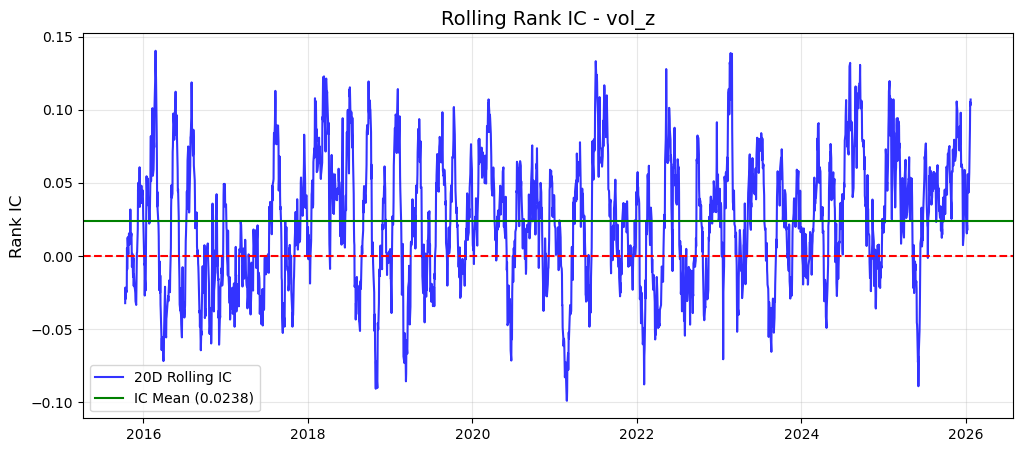

In [11]:
df = df_factor_ready.reset_index() if 'date' not in df_factor_ready.columns else df_factor_ready.copy()
print("=== 因子 IC 表现 ===")
ic_metrics = calc_ic_metrics(df, factor_col='vol_z', ret_cols={'1D': 'next_ret'})
print(ic_metrics)
print("-" * 30)

# 画滚动 IC 曲线，并获取每日 IC 序列
daily_ic = plot_rolling_ic(df, factor_col='vol_z', ret_col='next_ret', window=20)

分组与多空回测

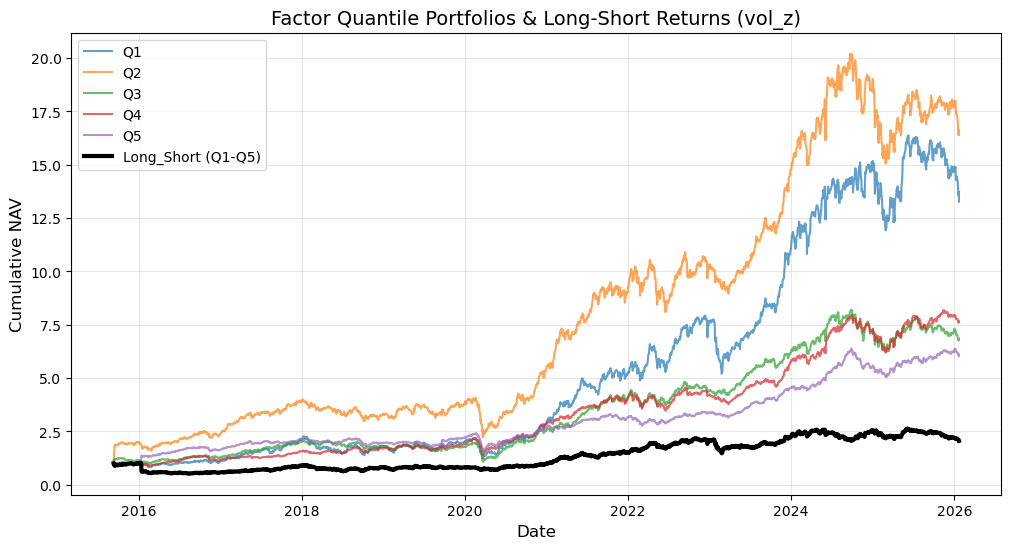

In [12]:
# 计算分组每日收益 (分5组)
group_ret = calc_long_short_returns(df, factor_col='vol_z', ret_col='next_ret', q=5)

# 低波因子的多空方向：做多最低波(Group_0)，做空最高波(Group_4)
group_ret['Long_Short (Q1-Q5)'] = group_ret['Group_0'] - group_ret['Group_4']

# 剔除原函数默认计算的相反方向的多空列，避免画图干扰
if 'Long_Short' in group_ret.columns:
    group_ret = group_ret.drop(columns=['Long_Short'])

#计算累计净值
cum_ret = (1 + group_ret).cumprod()

# 绘制累计收益曲线
plt.figure(figsize=(12, 6))

for col in cum_ret.columns:
    if 'Long_Short' in col:
        # 突出显示多空对冲曲线
        plt.plot(cum_ret.index, cum_ret[col], label=col, linewidth=3, color='black')
    else:
        # 普通分组曲线 (把 Group_0 替换为 Q1 方便阅读)
        label_name = col.replace('Group_', 'Q')
        # Group_0 是 Q1，以此类推
        label_name = f"Q{int(col.split('_')[1]) + 1}" if 'Group_' in col else col
        plt.plot(cum_ret.index, cum_ret[col], label=label_name, alpha=0.7)

plt.title('Factor Quantile Portfolios & Long-Short Returns (vol_z)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative NAV', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

收益率、最大回撤和夏普

In [14]:
long_short_series = group_ret['Long_Short (Q1-Q5)']
performance_metrics = get_metrics(long_short_series)

print("=== 多空对冲组合 (做多低波Q1 - 做空高波Q5) 核心绩效 ===")
# 格式化打印输出
for metric_name, value in performance_metrics.items():
    print(f"{metric_name}:\t {value}")

print("-" * 45)

long_only_series = group_ret['Group_0'] # Group_0 就是 Q1
long_only_metrics = get_metrics(long_only_series)

print("=== 纯多头组合 (仅做多低波Q1) 核心绩效 ===")
for metric_name, value in long_only_metrics.items():
    print(f"{metric_name}:\t {value}")


long_only_series = group_ret['Group_1'] # Q2的表现最好
long_only_metrics = get_metrics(long_only_series)

print("=== 纯多头组合 (仅做多低波Q2) 核心绩效 ===")
for metric_name, value in long_only_metrics.items():
    print(f"{metric_name}:\t {value}")

=== 多空对冲组合 (做多低波Q1 - 做空高波Q5) 核心绩效 ===
年化收益率:	 7.33%
年化波动率:	 23.13%
最大回撤:	 -49.50%
夏普比率:	 0.30
---------------------------------------------
=== 纯多头组合 (仅做多低波Q1) 核心绩效 ===
年化收益率:	 28.91%
年化波动率:	 26.98%
最大回撤:	 -45.33%
夏普比率:	 0.97
=== 纯多头组合 (仅做多低波Q2) 核心绩效 ===
年化收益率:	 31.62%
年化波动率:	 32.39%
最大回撤:	 -45.35%
夏普比率:	 0.89


# RSI

In [22]:
def rsi_signal(close, n=14, overbought=70, oversold=30):
    """
    基于RSI指标生成买卖信号 (1=超卖买入，-1=超买卖出，0=无信号)
    性能优化版：使用 Pandas内置的 ewm 替代低效的 for 循环
    """
    # 计算价格变动
    price_change = close.diff()
    
    # 区分上涨变动(gain)和下跌变动(loss)
    gain = price_change.where(price_change > 0, 0)
    loss = -price_change.where(price_change < 0, 0)
    
    # 使用指数加权移动平均(ewm)替代 for 循环，alpha=1/n 完全等价于 Wilder's Smoothing
    avg_gain = gain.ewm(alpha=1/n, min_periods=n, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/n, min_periods=n, adjust=False).mean()
    
    # 计算相对强弱RS和RSI
    rs = avg_gain / avg_loss.replace(0, 1e-10)
    rsi = 100 - (100 / (1 + rs))
    
    # 生成信号
    signal = pd.Series(0, index=close.index)
    signal[rsi < oversold] = 1      # 超卖买入
    signal[rsi > overbought] = -1   # 超买卖出
    
    return signal

In [23]:
df_daily_rsi = df_daily.copy()
df_daily_rsi['signal'] = df_daily_rsi.groupby(level='symbol')['close'].transform(
    lambda x: rsi_signal(x, n=14, overbought=70, oversold=30))

# 计算未来收益并清洗异常数据 
df_daily_rsi['close_clean'] = df_daily_rsi['close'].replace(0, np.nan)
df_daily_rsi['ret_5d'] = df_daily_rsi.groupby(level='symbol')['close_clean'].shift(-5) / df_daily_rsi['close_clean'] - 1

# 提取有效的买入信号进行评估
all_buys_rsi = df_daily_rsi[(df_daily_rsi['signal'] == 1) & (df_daily_rsi['ret_5d'].notna())].copy()

# 剔除 inf 和极端错误数据
all_buys_rsi['ret_5d'] = all_buys_rsi['ret_5d'].replace([np.inf, -np.inf], np.nan)
all_buys_rsi.dropna(subset=['ret_5d'], inplace=True)

# 打印真实回测结果
if not all_buys_rsi.empty:
    win_rate = (all_buys_rsi['ret_5d'] > 0).mean() * 100
    avg_return = all_buys_rsi['ret_5d'].mean() * 100

    print("-" * 30)
    print(f"[RSI 策略表现]")
    print(f"清洗后触发买入总次数: {len(all_buys_rsi)}")
    print(f"持仓 5 天的胜率: {win_rate:.2f}%")
    print(f"持仓 5 天的平均单次收益: {avg_return:.2f}%")
    print("-" * 30)

------------------------------
[RSI 策略表现]
清洗后触发买入总次数: 8342
持仓 5 天的胜率: 52.61%
持仓 5 天的平均单次收益: 0.18%
------------------------------


# MACD

In [25]:
def macd_signal(close, fast=12, slow=26, signal_period=9):
    """
    基于MACD金叉/死叉生成买卖信号 (1=买入，-1=卖出，0=无信号)
    包含冷启动屏蔽与缺失值处理的工业版
    """
    # 缺失值前向填充（防止停牌导致信号断裂）
    close_filled = close.ffill()
    
    #计算12日EMA和26日EMA
    ema_fast = close_filled.ewm(span=fast, adjust=False).mean()
    ema_slow = close_filled.ewm(span=slow, adjust=False).mean()
    
    #计算DIF(快线)和DEA(慢线)
    dif = ema_fast - ema_slow
    dea = dif.ewm(span=signal_period, adjust=False).mean()
    
    # 判定金叉/死叉 (处理边界：显式判断不为 NaN)
    prev_dif = dif.shift(1)
    prev_dea = dea.shift(1)
    
    golden_cross = (prev_dif < prev_dea) & (dif > dea)
    death_cross = (prev_dif > prev_dea) & (dif < dea)
    
    #生成信号序列
    signal = pd.Series(0, index=close.index)
    signal[golden_cross] = 1
    signal[death_cross] = -1
    
    # 前 slow + signal_period 天指标未收敛，不发信号
    warmup_period = slow + signal_period
    if len(signal) > warmup_period:
        signal.iloc[:warmup_period] = 0
        
    return signal